### This notebook explores the clusters formed by various unsupervised learning algorithms. The reader is expected to have basic knowledge of how K-means work.

We will be discussing the partional algorithms which divides the dataset into several clusters. In case of Kmeans where we need to know the number of clusters and in case of DBSCAN we dont. 
(But the catch with DBSCAN is that we have two hyperparameters epsilon and min-samples that we will see below in the notebook. The DBSCAN method is left for readers to explore )

Defining the number of clusters before hand requires domain knowledge which can be challenging. Various methods like the elbow chart, silhoute distance method, gap statistics are developed to bridge the shortcommings. 

In [164]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.cluster import KMeans
# from sklearn.cluster import AgglomerativeClustering, DBSCAN, AffinityPropagation TODO Explore this later

from sklearn.metrics import silhouette_score
import plotly as py
import plotly.graph_objs as go
# import scipy.cluster.hierarchy as sch

In [165]:
df = pd.read_csv('Mall_Customers.csv')
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [166]:
print(df.shape)

(200, 5)


In [167]:
print(df.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [168]:
# check for missing data
print(df.isnull().sum()) 

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


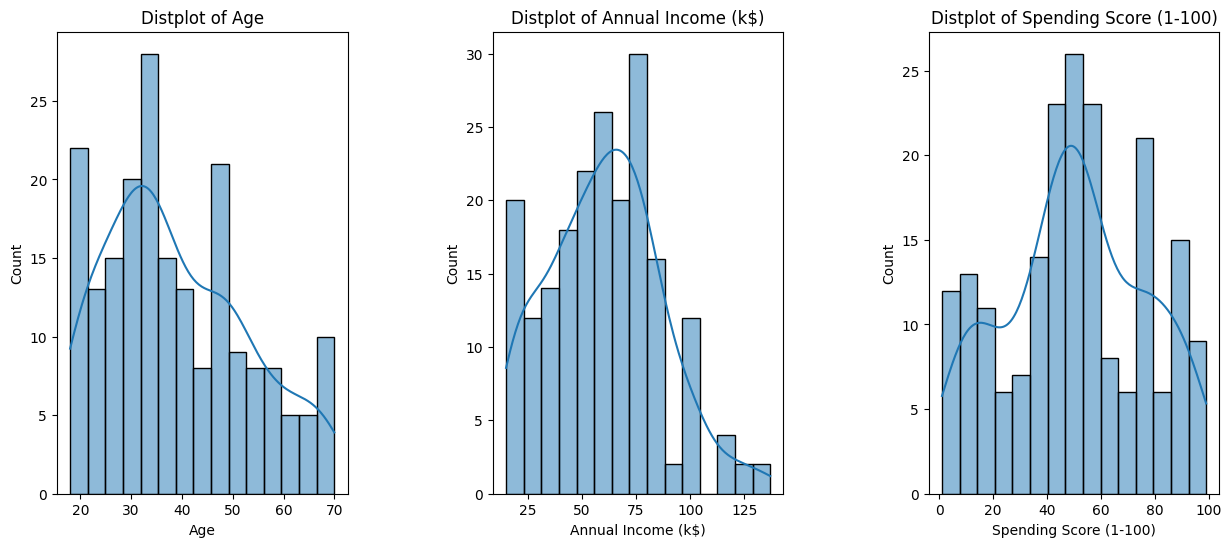

In [169]:
# Lets see how vales are distributed
plt.figure(1 , figsize = (15 , 6)) 
n = 0 
for x in ['Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']:
    n += 1
    plt.subplot(1 , 3 , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    sns.histplot(df[x] , bins = 15, kde=True)
    plt.title('Distplot of {}'.format(x))
plt.show()

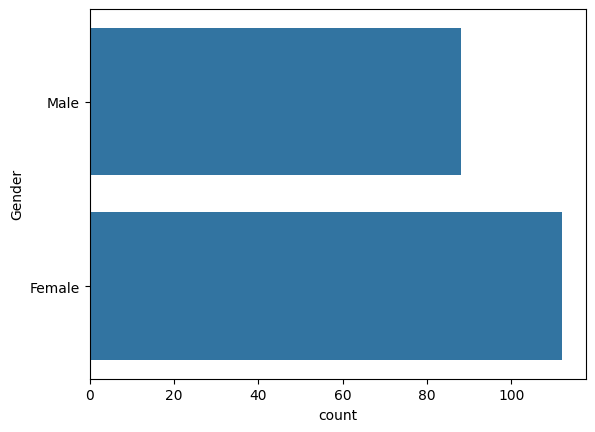

In [170]:
# count males / females
sns.countplot(y='Gender', data=df)
plt.show()

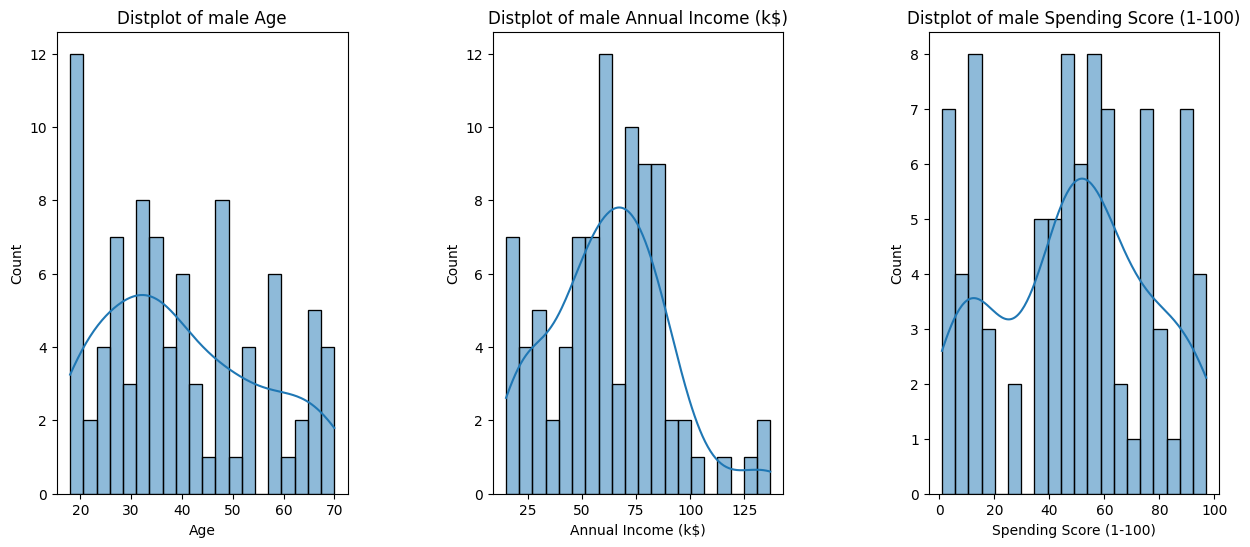

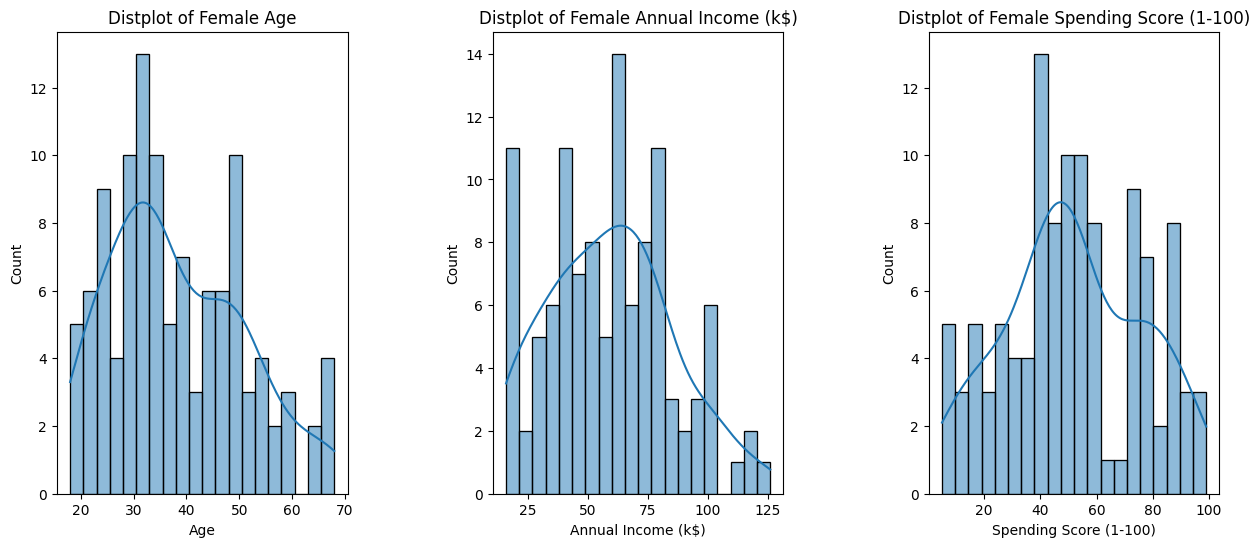

In [171]:
#Subsetting the dataframes for different gender groups
df_male = df[df['Gender'] == 'Male']
df_female = df[df['Gender'] == 'Female']

#Explore the Age , Income and Spending score for Males
plt.figure(1 , figsize = (15 , 6))
n = 0 
for x in ['Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']:
    n += 1
    plt.subplot(1 , 3 , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    sns.histplot(df_male[x] , bins = 20, kde=True)
    plt.title('Distplot of male {}'.format(x))
plt.show()

#Explore the Age, Income and Spending score of Females
plt.figure(1 , figsize = (15 , 6))
n = 0 
for x in ['Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']:
    n += 1
    plt.subplot(1 , 3 , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    sns.histplot(df_female[x] , bins = 20, kde=True)
    plt.title('Distplot of Female {}'.format(x))
plt.show()

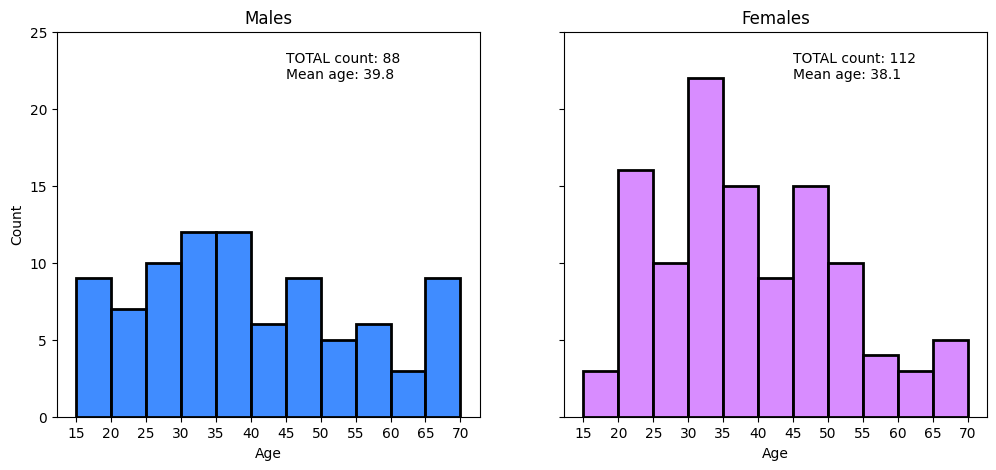

In [172]:
# Investigate different age groups for males and females

df_male_age   = df[df['Gender']=='Male']['Age']   # subset with males age
df_female_age = df[df['Gender']=='Female']['Age'] # subset with females age

# Lets plot histogram based of column age

age_bins = range(15,75,5) # sequence starting from 15 up to (but not including) 75, with a step size of 5.

# males histogram
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5), sharey=True)
sns.histplot(df_male_age, bins=age_bins, kde=False, color='#0066ff', ax=ax1, edgecolor="k", linewidth=2)
ax1.set_xticks(age_bins)
ax1.set_ylim(top=25)
ax1.set_title('Males')
ax1.set_ylabel('Count')
ax1.text(45,23, "TOTAL count: {}".format(df_male_age.count()))
ax1.text(45,22, "Mean age: {:.1f}".format(df_male_age.mean()))

# females histogram
sns.histplot(df_female_age, bins=age_bins, kde=False, color='#cc66ff', ax=ax2, edgecolor="k", linewidth=2)
ax2.set_xticks(age_bins)
ax2.set_ylim(top=25)
ax2.set_title('Females')
ax2.set_ylabel('Count')
ax2.text(45,23, "TOTAL count: {}".format(df_female_age.count()))
ax2.text(45,22, "Mean age: {:.1f}".format(df_female_age.mean()))

plt.show()

- The average age of male customers is lightly higher than female ones (39.8 versus 38.1).
- Distribution of male age is more uniform than females, where we can observe that the biggest age group is 30-35 years old

Text(50, 13, 'Std. deviation score: 24.1')

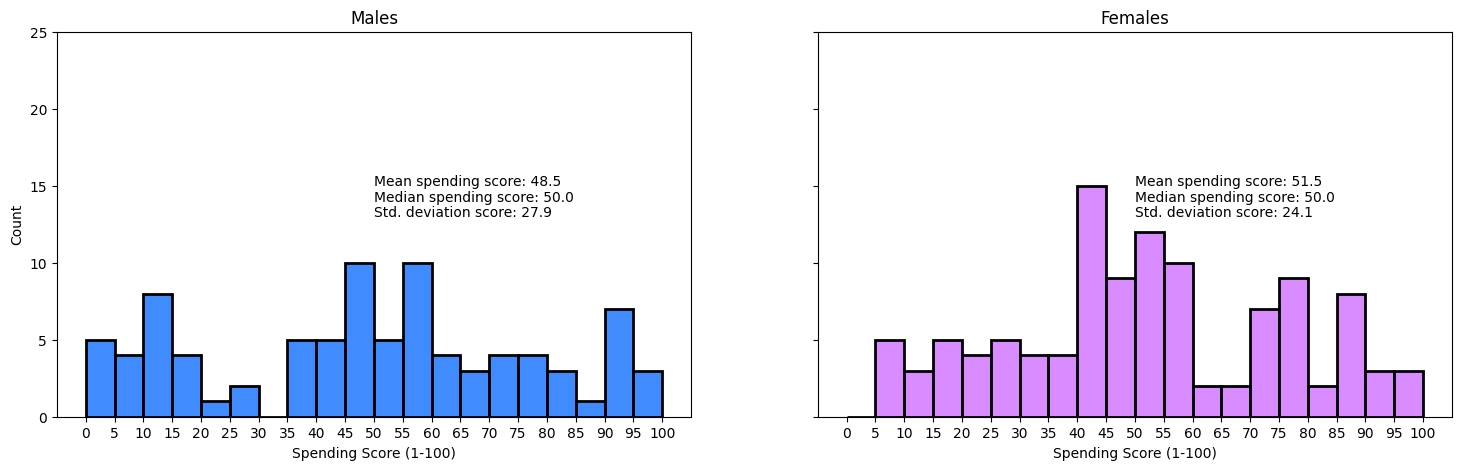

In [173]:
# Who spends more? 
male_spendings   = df[df['Gender']=='Male']['Spending Score (1-100)'] # subset with males spending power
female_spendings = df[df['Gender']=='Female']['Spending Score (1-100)'] # subset with spending power

spending_bin = range(0,105,5)

# males histogram
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(18,5), sharey=True)
sns.histplot(male_spendings, bins=spending_bin, kde=False, color='#0066ff', ax=ax1, edgecolor="k", linewidth=2)
ax1.set_xticks(spending_bin)
ax1.set_ylim(top=25)
ax1.set_title('Males')
ax1.set_ylabel('Count')
ax1.text(50,15, "Mean spending score: {:.1f}".format(male_spendings.mean()))
ax1.text(50,14, "Median spending score: {:.1f}".format(male_spendings.median()))
ax1.text(50,13, "Std. deviation score: {:.1f}".format(male_spendings.std()))

# females histogram
sns.histplot(female_spendings, bins=spending_bin, kde=False, color='#cc66ff', ax=ax2, edgecolor="k", linewidth=2)
ax2.set_xticks(spending_bin)
ax2.set_ylim(top=25)
ax2.set_title('Females')
ax2.set_ylabel('Count')
ax2.text(50,15, "Mean spending score: {:.1f}".format(female_spendings.mean()))
ax2.text(50,14, "Median spending score: {:.1f}".format(female_spendings.median()))
ax2.text(50,13, "Std. deviation score: {:.1f}".format(female_spendings.std()))


A mean spending score for women (51.5) is higher than men (48.5) hence **women spend more than man**

1 medians_by_age_group:
                   Age  Annual Income (k$)  Spending Score (1-100)
Gender Age_group                                                  
Female (15, 20]   19.0                63.0                    50.0
       (20, 25]   23.0                39.0                    65.0
       (25, 30]   29.0                74.5                    73.0
       (30, 35]   32.0                70.0                    69.0
       (35, 40]   38.0                73.5                    41.0
       (40, 45]   44.0                73.0                    28.0
       (45, 50]   49.0                54.0                    44.5
       (50, 55]   54.0                57.0                    43.0
       (55, 60]   58.0                50.0                    35.0
       (60, 65]   64.0                51.5                    39.0
       (65, 70]   67.5                53.5                    51.0
Male   (15, 20]   19.0                53.5                    47.5
       (20, 25]   24.0                

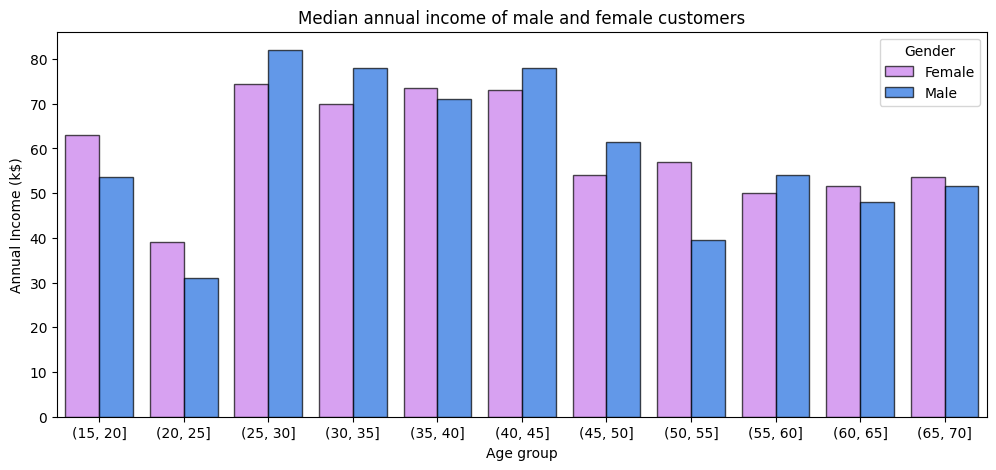

In [174]:
# Lets find Median annual income of male and female customers based on age group

ages_cut = pd.cut(df['Age'], age_bins) # categorizes (or "bins") the Age column into predefined intervals (age_bins).
df_no_id = df.drop(columns=['CustomerID'])

medians_by_age_group = df_no_id.groupby(["Gender",ages_cut], observed=False).median()

medians_by_age_group.index = medians_by_age_group.index.set_names(['Gender', 'Age_group'])
print(f"1 medians_by_age_group:\n{medians_by_age_group}")
print("######################################")
print("Or printing in  different style:")

medians_by_age_group.reset_index(inplace=True)# converts the MultiIndex (which was "Gender" and "Age_group") back into regular columns.
print(f"medians_by_age_group:\n{medians_by_age_group}")
print("######################################")


# Lets plot the graph to get better visual:
# Lets see who makes more money based on age ranges
fig, ax = plt.subplots(figsize=(12,5))
sns.barplot(x='Age_group', y='Annual Income (k$)', hue='Gender', data=medians_by_age_group,
            palette=['#cc66ff','#0066ff'],
            alpha=0.7,edgecolor='k',
            ax=ax)
ax.set_title('Median annual income of male and female customers')
ax.set_xlabel('Age group')
plt.show()

For Females the age groups of 35-45 earn the most and Female 35-40 age group overshadows the earnings of male. 

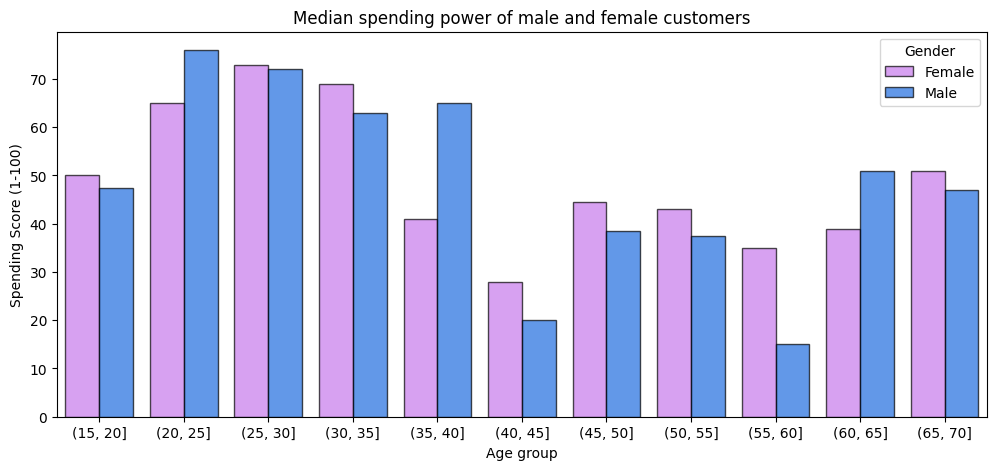

In [175]:
# Lets see who spends more based on age range
fig, ax = plt.subplots(figsize=(12,5))
sns.barplot(x='Age_group',
            y='Spending Score (1-100)',
            hue='Gender', 
            data=medians_by_age_group,
            palette=['#cc66ff','#0066ff'],
            alpha=0.7,edgecolor='k',
            ax=ax)
ax.set_title('Median spending power of male and female customers')
ax.set_xlabel('Age group')
plt.show()

Age group of male from 20-25 has the highest spending power and age group of females from 25-30 has the highest spending power

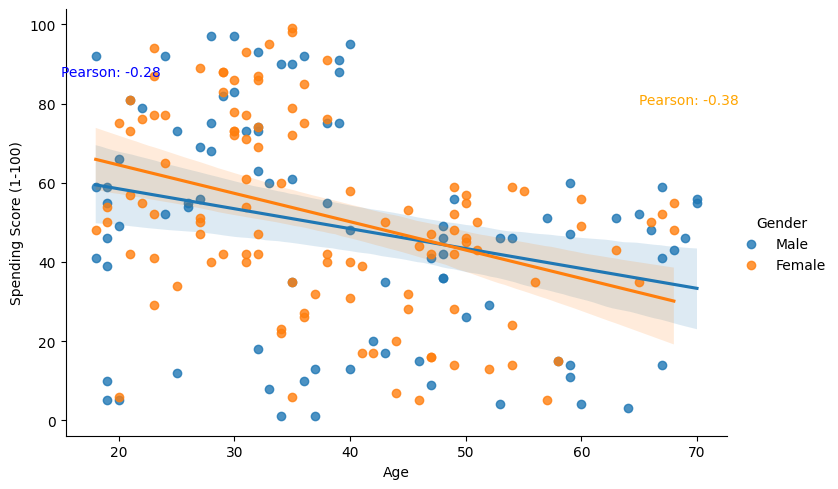

In [176]:
# calculating Pearson's correlation betweem age groups and spending power
from scipy.stats import pearsonr

corr1, _ = pearsonr(df_male_age.values,   male_spendings.values)
corr2, _ = pearsonr(df_female_age.values, female_spendings.values)

sns.lmplot(x='Age',
           y='Spending Score (1-100)',
           data=df,
           hue='Gender',
           aspect=1.5
)
plt.text(15,87, 'Pearson: {:.2f}'.format(corr1), color='blue')
plt.text(65,80, 'Pearson: {:.2f}'.format(corr2), color='orange')

plt.show()

We see very low negative correlation between age and spending score (1-00). We can similarly find out how are other factors related to each other. 

# Clustering 

### Kmeans

The most well-known partitional clustering algorithm is K-Means. 
There are 3 main steps in K-Means algorithm (known also as Lloyd’s algorithm):

1. Split samples into initial groups by using seed points. The nearest samples to these seed point will create initial clusters.
2. Calculate samples distances to groups’ central points (centroids) and assign the nearest samples to their cluster.
3. The third step is to calculate newly created (updated) cluster centroids.

Then repeat steps 2 and 3 until the algorithm converges.

This is known as NP-hard problem, meaning this is a greedy algorithm and converges to the local minimum. The computational cost of Lloyd’s K-Means algorithm is O(kn), where k is a number of clusters and n is a number of samples. This is not bad when compared with other clustering algorithms. Despite converging usually to a local minimum, K-means is relatively fast and when groups are well isolated from each other it is likely that it converges to the global minimum. Because the result of clusterisation depends on the initialisation criteria it is common to run the analysis for various initialisation points and choose the one with minimum resultant inertia. There are some improvements to the algorithm solving problem of the local minima.

In general, a user of the K-Means algorithm is required to define three main parameters:

##### Initialisation criteria
In scikit-learn, a clever initialisation scheme is implemented: “k-means++” proposed by Arthur and Vassilvitskii. It creates initial centroids generally distant from each other increasing probability of obtaining better results. There is also a possibility to use a random point’s generator. There are ongoing efforts to create the most efficient seeding method for K-Means algorithm, one of them is based on Independent Component Analysis.

##### Number of clusters
Selecting a number of clusters is the most challenging part of setting this algorithm. There are no hard mathematical criteria for this and many heuristic/simplified approaches have been developed. One of the simplest and the most popular one is the elbow method shown in this analysis. Additionaly a silhouette score will be used as well. There are also other, often advanced, options for choosing the optimal number of clusters (however, not used in this notebook and not implemented in sklearn).

##### A distance metric (not required in scikit learn implementation)
There are various options to calculate the distance between points. The most popular one is simply the Euclidean metric and it is the one implemented in scikit-learn. It is often called spherical k-means model. It has a drawback that it finds spherical-like groups only and tends to become inflated in highly multi-dimensional analyses (“curse of dimensionality”). 

There are numerous ongoing researches and variations proposed to K-Means, e.g.:

K-Medoid where the centroid is defined as the most centrally located object)
K-Median where the centroid is calculated using median instead of a mean,
Fuzzy C-means model

##### Some take-aways about K-Means:

* Euclidean distances are used
* Number of clusters has to be defined for the algorithm
* Centroid is calculated using mean distance to cluster members
* Clusters are assumed isotropic and convex
* Stochastic algorithm – results depend on the initialisation criteria
* Creates groups of equal variance (minimises inertia)
* Prone to the “curse of dimensionality”
* Can be run in parallel – so it scales well

### Perfoming segmentation using 2 variables

#### Age and spending Score

In [177]:
# Lets find the right number of clusters using elbow method
X1 = df[['Age' , 'Spending Score (1-100)']].iloc[: , :].values
inertia = []
s_scores = []
for n in range(2 , 11):
    algorithm = (KMeans(n_clusters = n ,init='k-means++', n_init = 10 ,max_iter=300, 
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
    algorithm.fit(X1)
    inertia.append(algorithm.inertia_)
    silhouette_avg = silhouette_score(X1, algorithm.labels_)
    s_scores.append(silhouette_avg) # data for the silhouette score method

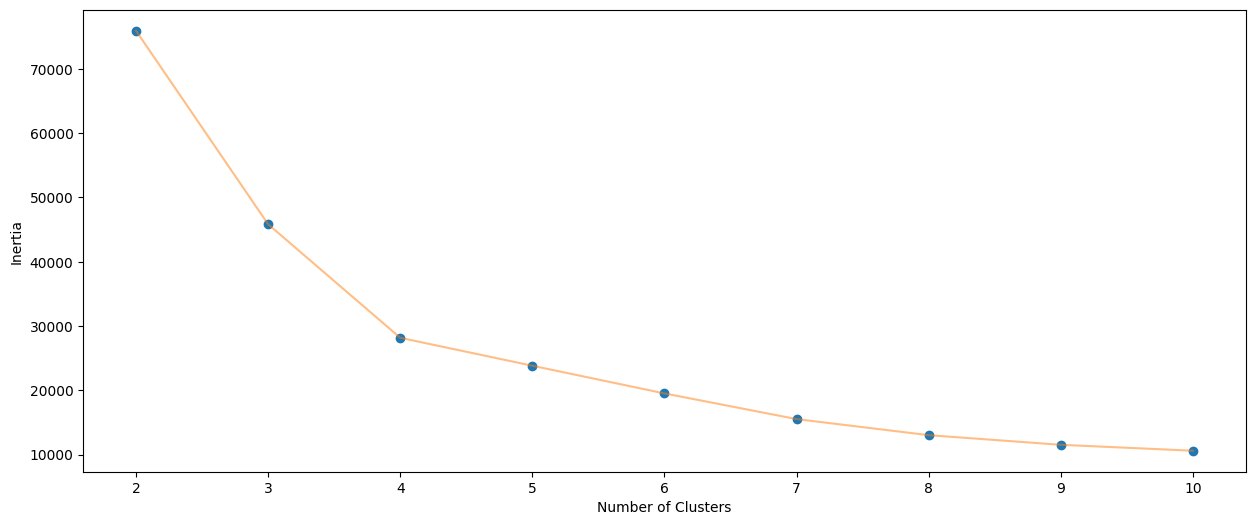

In [178]:
#The Elbow Chart
plt.figure(1 , figsize = (15 ,6))
plt.plot(np.arange(2 , 11) , inertia , 'o')
plt.plot(np.arange(2 , 11) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

Now we are unclear which clusters to go for 4 or 5 or 6. Here we use <b>The Silhouette Method</b>. The silhouette value measures how similar a point is to its own cluster (cohesion) compared to other clusters (separation).The range of the Silhouette value is between +1 and -1. A high value is desirable and indicates that the point is placed in the correct cluster. If many points have a negative Silhouette value, it may indicate that we have created too many or too few clusters.

I mentioned before that a high Silhouette Score is desirable. The Silhouette Score reaches its global maximum at the optimal k. This should ideally appear as a peak in the Silhouette Value-versus-k plot.

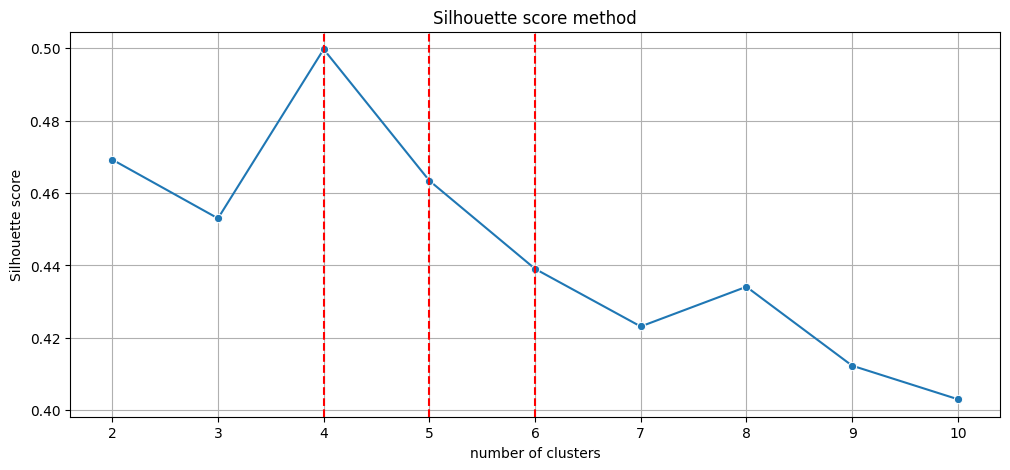

In [179]:

fig, ax = plt.subplots(figsize=(12,5))
ax = sns.lineplot(x=np.arange(2, 11), y=s_scores, marker='o', ax=ax)

ax.set_title("Silhouette score method")
ax.set_xlabel("number of clusters")
ax.set_ylabel("Silhouette score")
ax.axvline(4, ls="--", c="red")
ax.axvline(5, ls="--", c="red")
ax.axvline(6, ls="--", c="red")
plt.grid()
plt.show()

We see that silhoutte score is maximum at k=4. So we go ahead and take that value

The Elbow Method is more of a decision rule, while the Silhouette is a metric used for validation while clustering. Thus, it can be used in combination with the Elbow Method.

In [180]:
# Now we find 4 clusters using K means
KM4 = (KMeans(n_clusters = 4 ,init='k-means++', n_init = 10 ,max_iter=300, 
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
KM4.fit(X1)
labels1    = KM4.labels_
centroids1 = KM4.cluster_centers_

In [182]:
h = 0.02
x_min, x_max = X1[:, 0].min() - 1, X1[:, 0].max() + 1
y_min, y_max = X1[:, 1].min() - 1, X1[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = KM4.predict(np.c_[xx.ravel(), yy.ravel()]) 

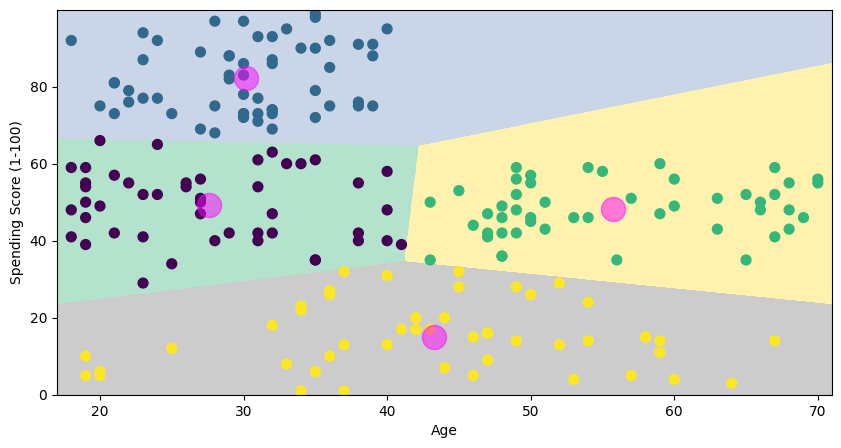

In [183]:
plt.figure(1 , figsize = (10 , 5) )
plt.clf()
Z = Z.reshape(xx.shape)
plt.imshow(Z ,
           interpolation='nearest', 
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap = plt.cm.Pastel2,
           aspect = 'auto', origin='lower'
)
plt.scatter( x='Age', y='Spending Score (1-100)', data=df, c=labels1, s=50 )
plt.scatter(x=centroids1[: , 0], y=centroids1[: , 1], s=300, c='magenta', alpha=0.5)
plt.ylabel('Spending Score (1-100)') 
plt.xlabel('Age')
plt.show()

Similarly we can go for the combinations of all other pair of variables

### Perfoming segmentation using all the numeric variables
- In above we were only using 2 variables. Now we use all variables

In [184]:
columns=['Age' ,'Annual Income (k$)' ,'Spending Score (1-100)']
X = df[columns]
inertia = []
s_scores = []
for n in range(2 , 11):
    KM_n = KMeans(n_clusters = n ,init='k-means++', n_init = 10 ,max_iter=300, 
                        tol=0.0001,  random_state= 111  , algorithm='elkan').fit(X) 
    inertia.append(KM_n.inertia_)
    silhouette_avg = silhouette_score(X, KM_n.labels_)
    s_scores.append(silhouette_avg) # data for the silhouette score method

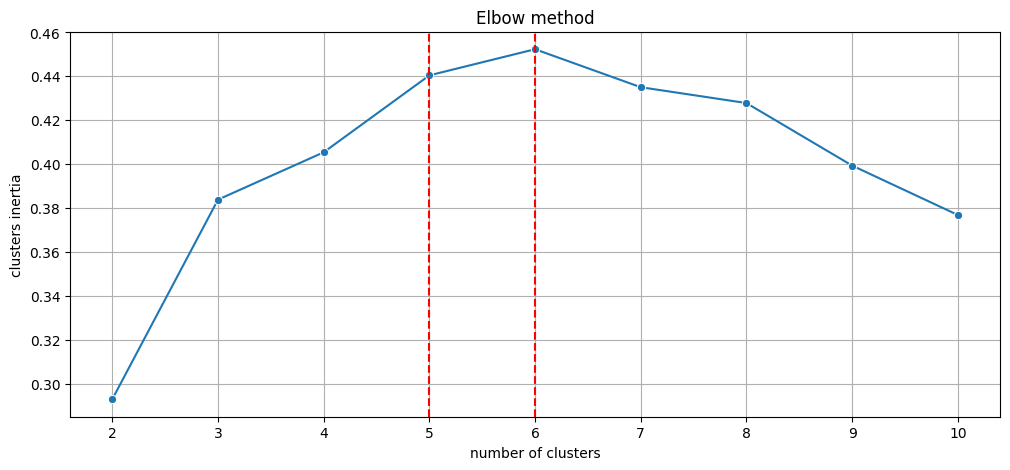

In [185]:
fig, ax = plt.subplots(figsize=(12,5))
# ax = sns.lineplot(np.arange(2 , 11), inertia, marker='o', ax=ax)
ax = sns.lineplot(x=np.arange(2, 11), y=s_scores, marker='o', ax=ax)
ax.set_title("Elbow method")
ax.set_xlabel("number of clusters")
ax.set_ylabel("clusters inertia")
ax.axvline(5, ls="--", c="red")
ax.axvline(6, ls="--", c="red")
plt.grid()
plt.show()

A choice of 5 or 6 clusters seems to be fair. Let's see the silhouette score.

Silhouette score method indicates the best options would be respectively 6 or 5 clusters. Let's compare both.

In [187]:
# For clusters of K=6
KM6 = (KMeans(n_clusters=6, 
              init='k-means++',
              n_init = 10,
              max_iter=300,
              tol=0.0001,
              random_state= 111,
              algorithm='elkan') 
)
KM6.fit(X)
labels6    = KM6.labels_
centroids6 = KM6.cluster_centers_
KM6_df = df.copy()
KM6_df['labels'] = labels6

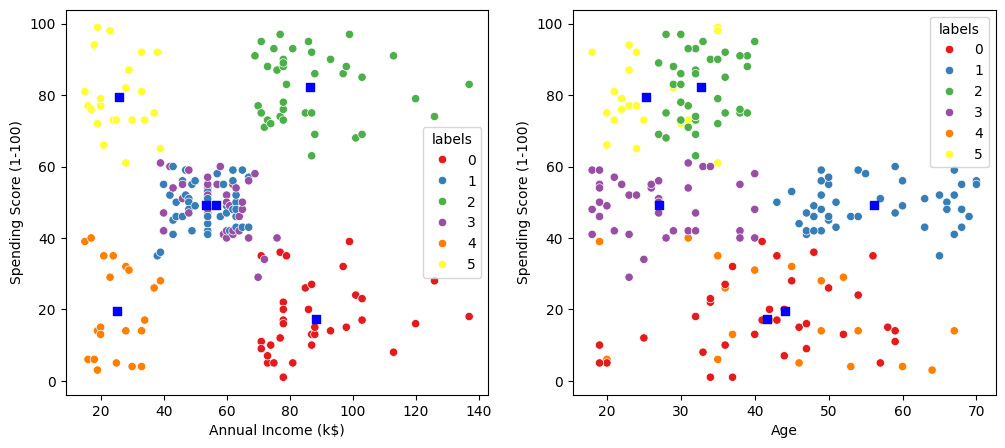

Point 0: Age = 19, Annual Income (k$) = 15, Spending Score (1-100) = 39, Cluster = 4
Point 1: Age = 21, Annual Income (k$) = 15, Spending Score (1-100) = 81, Cluster = 5
Point 2: Age = 20, Annual Income (k$) = 16, Spending Score (1-100) = 6, Cluster = 4
Point 3: Age = 23, Annual Income (k$) = 16, Spending Score (1-100) = 77, Cluster = 5
Point 4: Age = 31, Annual Income (k$) = 17, Spending Score (1-100) = 40, Cluster = 4
Point 5: Age = 22, Annual Income (k$) = 17, Spending Score (1-100) = 76, Cluster = 5
Point 6: Age = 35, Annual Income (k$) = 18, Spending Score (1-100) = 6, Cluster = 4
Point 7: Age = 23, Annual Income (k$) = 18, Spending Score (1-100) = 94, Cluster = 5
Point 8: Age = 64, Annual Income (k$) = 19, Spending Score (1-100) = 3, Cluster = 4
Point 9: Age = 30, Annual Income (k$) = 19, Spending Score (1-100) = 72, Cluster = 5
Point 10: Age = 67, Annual Income (k$) = 19, Spending Score (1-100) = 14, Cluster = 4
Point 11: Age = 35, Annual Income (k$) = 19, Spending Score (1-100)

In [188]:
# Lets plot the clusters with each data point assigend to the clusters

fig1, (axes) = plt.subplots(1,2,figsize=(12,5))

scat_1 = sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=KM6_df,
                hue='labels', ax=axes[0], palette='Set1', legend='full')

sns.scatterplot(x='Age', y='Spending Score (1-100)', data=KM6_df,
                hue='labels', palette='Set1', ax=axes[1], legend='full')

axes[0].scatter(centroids6[:,1],centroids6[:,2], marker='s', s=40, c="blue")
axes[1].scatter(centroids6[:,0],centroids6[:,2], marker='s', s=40, c="blue")
plt.show()

#Following is optional
# Now, print the coordinates and their corresponding cluster labels after the plot is shown
for i in range(len(KM6_df)):
    print(f"Point {i}: Age = {KM6_df['Age'].iloc[i]}, "
          f"Annual Income (k$) = {KM6_df['Annual Income (k$)'].iloc[i]}, "
          f"Spending Score (1-100) = {KM6_df['Spending Score (1-100)'].iloc[i]}, "
          f"Cluster = {KM6_df['labels'].iloc[i]}")

K-Means algorithm generated the following 6 clusters:

* younger clients with **medium** annual and **medium** spending score
* clients with **high** annual income and **low** spending score
* younger clients with **medium** annual and **medium** spending score
* clients with **high** annual income and **high** spending score
* clients with **low** annual income and **low** spending score
* clients with **low** annual income and **high** spending score

There are no distinct groups is terms of customers age.

In [189]:
KM_clust_sizes = KM6_df.groupby('labels').size().to_frame()
KM_clust_sizes.columns = ["KM_size"]
print(KM_clust_sizes)

        KM_size
labels         
0            35
1            45
2            39
3            38
4            21
5            22


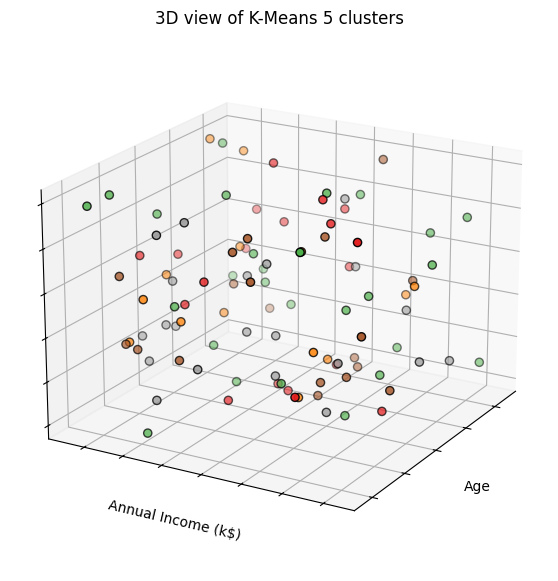

In [190]:
from mpl_toolkits.mplot3d import Axes3D

# Sample Data (Replace KM6_df with your actual DataFrame)
np.random.seed(42)
KM6_df = pd.DataFrame({
    'Age': np.random.randint(18, 65, 100),
    'Annual Income (k$)': np.random.randint(15, 150, 100),
    'Spending Score (1-100)': np.random.randint(1, 100, 100),
    'labels': np.random.randint(0, 5, 100)
})

# Create 3D Plot
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d', elev=20, azim=210)

ax.scatter(KM6_df['Age'],
           KM6_df['Annual Income (k$)'],
           KM6_df['Spending Score (1-100)'],
           c=KM6_df['labels'],
           s=35, edgecolor='k', cmap=plt.cm.Set1)

# Corrected tick removal method
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

# Labels and title
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('3D view of K-Means 5 clusters')

ax.dist = 12  # Adjusting the distance for better view

plt.show()


In [191]:
import plotly as py
import plotly.graph_objs as go

def tracer(db, n, name):
    '''
    This function returns trace object for Plotly
    '''
    return go.Scatter3d(
        x = db[db['labels']==n]['Age'],
        y = db[db['labels']==n]['Spending Score (1-100)'],
        z = db[db['labels']==n]['Annual Income (k$)'],
        mode = 'markers',
        name = name,
        marker = dict(
            color = KM6_df['labels'],
            size = 5,
            line=dict(
            color= KM6_df['labels'],
            width= 12
        ),
        opacity=0.8
        )
     )

trace0 = tracer(KM6_df, 0, 'Cluster 0')
trace1 = tracer(KM6_df, 1, 'Cluster 1')
trace2 = tracer(KM6_df, 2, 'Cluster 2')
trace3 = tracer(KM6_df, 3, 'Cluster 3')
trace4 = tracer(KM6_df, 4, 'Cluster 4')
trace5 = tracer(KM6_df, 5, 'Cluster 5')

trace_data = [trace0, trace1, trace2, trace3, trace4, trace5]

layout = go.Layout(
    title = 'Clusters with k=6 wrt Age, Income and Spending Scores',
    scene = dict(
            xaxis = dict(title = 'Age'),
            yaxis = dict(title = 'Spending Score'),
            zaxis = dict(title = 'Annual Income')
        )
)

fig = go.Figure(data=trace_data, layout=layout)
py.offline.iplot(fig)


In [192]:
#For clusters of K=5
KM5 = (KMeans(n_clusters = 5 ,init='k-means++', n_init = 10 ,max_iter=300, 
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
KM5.fit(X)
labels5 = KM5.labels_
centroids5 = KM5.cluster_centers_
KM5_df = df.copy()
KM5_df['labels'] = labels5

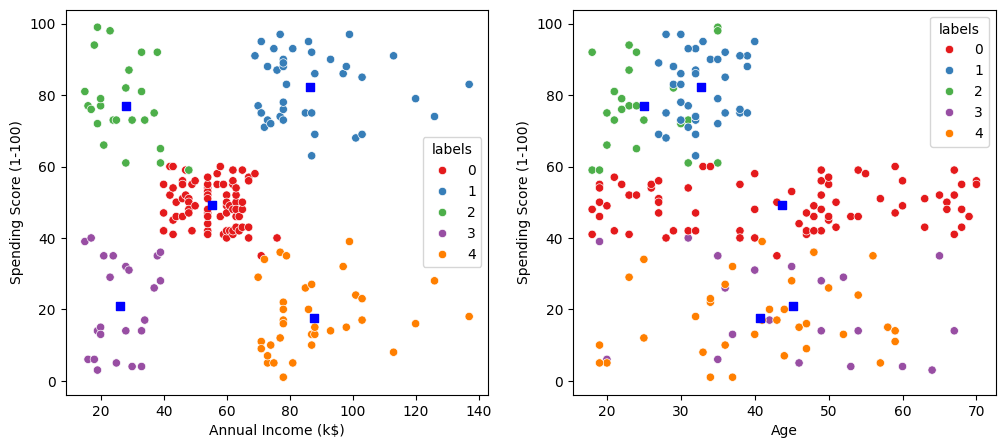

In [193]:
fig1, (axes) = plt.subplots(1,2,figsize=(12,5))


scat_1 = sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=KM5_df,
                hue='labels', ax=axes[0], palette='Set1', legend='full')

sns.scatterplot(x='Age', y='Spending Score (1-100)', data=KM5_df,
                hue='labels', palette='Set1', ax=axes[1], legend='full')

axes[0].scatter(centroids5[:,1],centroids5[:,2], marker='s', s=40, c="blue")
axes[1].scatter(centroids5[:,0],centroids5[:,2], marker='s', s=40, c="blue")
plt.show()

K-Means algorithm generated the following 5 clusters:

* clients with **low** annual income and **high** spending score
* clients with **medium** annual income and **medium** spending score
* clients with **high** annual income and **low** spending score
* clients with **high** annual income and **high** spending score
* clients with **low** annual income and **low** spending score

There are no distinct groups is terms of customers age.

In [194]:
KM_clust_sizes5 = KM5_df.groupby('labels').size().to_frame()
KM_clust_sizes5.columns = ["KM_size"]
KM_clust_sizes5

,KM_size
labels,
0,77
1,39
2,25
3,23
4,36


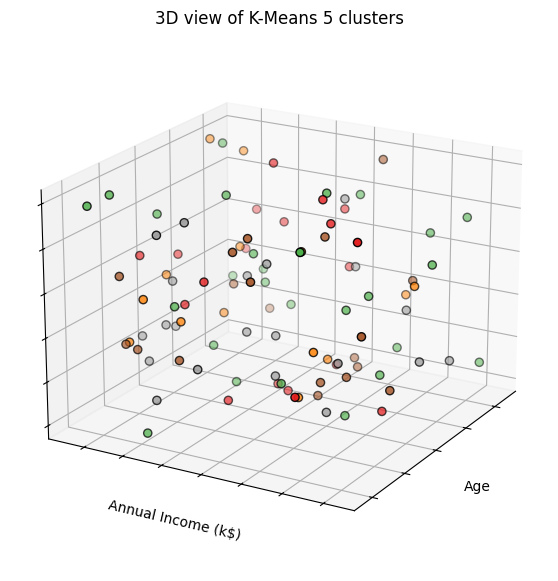

In [195]:
from mpl_toolkits.mplot3d import Axes3D

# Sample Data (Replace KM5_df with your actual DataFrame)
np.random.seed(42)
KM5_df = pd.DataFrame({
    'Age': np.random.randint(18, 65, 100),
    'Annual Income (k$)': np.random.randint(15, 150, 100),
    'Spending Score (1-100)': np.random.randint(1, 100, 100),
    'labels': np.random.randint(0, 5, 100)
})

# Create 3D Plot
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d', elev=20, azim=210)

ax.scatter(KM5_df['Age'],
           KM5_df['Annual Income (k$)'],
           KM5_df['Spending Score (1-100)'],
           c=KM5_df['labels'],
           s=35, edgecolor='k', cmap=plt.cm.Set1)

# Corrected tick removal method
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

# Labels and title
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('3D view of K-Means 5 clusters')

ax.dist = 12  # Adjusting the distance for better view

plt.show()


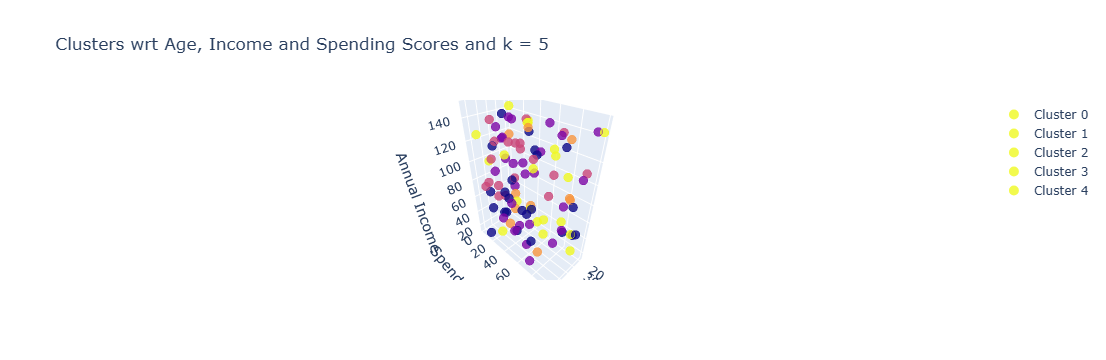

In [196]:
trace0 = tracer(KM5_df, 0, 'Cluster 0')
trace1 = tracer(KM5_df, 1, 'Cluster 1')
trace2 = tracer(KM5_df, 2, 'Cluster 2')
trace3 = tracer(KM5_df, 3, 'Cluster 3')
trace4 = tracer(KM5_df, 4, 'Cluster 4')

trace_data5 = [trace0, trace1, trace2, trace3, trace4]

layout = go.Layout(
    title = 'Clusters wrt Age, Income and Spending Scores and k = 5',
    scene = dict(
            xaxis = dict(title = 'Age'),
            yaxis = dict(title = 'Spending Score'),
            zaxis = dict(title = 'Annual Income')
        )
)

fig = go.Figure(data=trace_data5, layout=layout)
py.offline.iplot(fig)
